# 05 — Model Comparison
**Employee Feedback Intelligence Platform**

Side-by-side comparison of:
- **Classical ML** — LinearSVC + TF-IDF (Notebook 03)
- **Transformer** — DistilBERT fine-tuned (Notebook 04)

1. Load saved metrics from both models
2. Accuracy & Macro-F1 comparison
3. Per-class F1 comparison
4. Confusion matrices side-by-side
5. Speed vs accuracy trade-off
6. Final recommendation

In [ ]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import joblib
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
)
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

warnings.filterwarnings('ignore')

RANDOM_STATE  = 42
SAMPLE_SIZE   = 3000
LABELS_ORDER  = ['Negative', 'Neutral', 'Positive']
LABEL2ID      = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
ID2LABEL      = {v: k for k, v in LABEL2ID.items()}

DATA_PATH        = '../data/processed/cleaned.csv'
CLASSICAL_PKL    = '../models/classical_model.pkl'
TFIDF_PKL        = '../models/tfidf_vectorizer.pkl'
CLASSICAL_JSON   = '../models/classical_metrics.json'
TRANSFORMER_DIR  = '../models/transformer'
TRANSFORMER_JSON = '../models/transformer_metrics.json'
ASSETS_DIR       = '../assets'


print('Config ready')

Config ready


In [2]:
with open(CLASSICAL_JSON) as f:
    classical_metrics = json.load(f)

with open(TRANSFORMER_JSON) as f:
    transformer_metrics = json.load(f)

print('Classical  :', classical_metrics['model'])
print(f"  Accuracy : {classical_metrics['test_accuracy']}")
print(f"  Macro-F1 : {classical_metrics['test_macro_f1']}")
print()
print('Transformer:', transformer_metrics['model'])
print(f"  Accuracy : {transformer_metrics['test_accuracy']}")
print(f"  Macro-F1 : {transformer_metrics['test_macro_f1']}")

Classical  : LinearSVC (tuned)
  Accuracy : 0.6874
  Macro-F1 : 0.5493

Transformer: distilbert-base-uncased (fine-tuned, PyTorch + HuggingFace Trainer)
  Accuracy : 0.52
  Macro-F1 : 0.5051


In [3]:
# ── Load & sample data (same seed as Notebooks 03 & 04) ──────────────
df = pd.read_csv(DATA_PATH)
df = df.dropna(subset=['text', 'sentiment'])
df = df.groupby('sentiment', group_keys=False).apply(
    lambda g: g.sample(min(len(g), SAMPLE_SIZE // 3), random_state=RANDOM_STATE)
).reset_index(drop=True)

# ── Classical split (uses clean_text) ────────────────────────────────
X_cl = df['clean_text'].fillna('')
y_cl = df['sentiment']
_, X_cl_test, _, y_cl_test = train_test_split(
    X_cl, y_cl, test_size=0.15, random_state=RANDOM_STATE, stratify=y_cl
)

# ── Transformer split (uses text) ────────────────────────────────────
X_tr = df['text'].values
y_tr = df['sentiment'].map(LABEL2ID).values
_, X_tr_test, _, y_tr_test = train_test_split(
    X_tr, y_tr, test_size=0.15, random_state=RANDOM_STATE, stratify=y_tr
)
y_tr_test_str = [ID2LABEL[l] for l in y_tr_test]

print(f'Classical test  : {len(y_cl_test):,} samples')
print(f'Transformer test: {len(y_tr_test):,} samples')

Classical test  : 450 samples
Transformer test: 450 samples


In [4]:
# ── Classical predictions ────────────────────────────────────────────
tfidf     = joblib.load(TFIDF_PKL)
clf       = joblib.load(CLASSICAL_PKL)
X_cl_vec  = tfidf.transform(X_cl_test)
y_cl_pred = clf.predict(X_cl_vec)

cl_acc = accuracy_score(y_cl_test, y_cl_pred)
cl_f1  = f1_score(y_cl_test, y_cl_pred, average='macro')
print(f'Classical  — Acc: {cl_acc:.4f}  Macro-F1: {cl_f1:.4f}')

Classical  — Acc: 0.5533  Macro-F1: 0.5081


In [9]:
import os
for f in os.listdir('../models/transformer'):
    print(f)

config.json
New Text Document.txt
tokenizer_config.json
training_args.bin


In [13]:
# ── Transformer predictions ──────────────────────────────────────────
import torch
from transformers import AutoModelForSequenceClassification, DistilBertTokenizerFast
from torch.utils.data import DataLoader, TensorDataset

tokenizer = DistilBertTokenizerFast.from_pretrained(TRANSFORMER_DIR)
model     = AutoModelForSequenceClassification.from_pretrained(TRANSFORMER_DIR)
device    = 'cuda' if torch.cuda.is_available() else 'cpu'
model.to(device).eval()

enc = tokenizer(list(X_tr_test), truncation=True, padding=True,
                max_length=128, return_tensors='pt')
ds  = TensorDataset(enc['input_ids'], enc['attention_mask'])
dl  = DataLoader(ds, batch_size=64)

all_preds = []
with torch.no_grad():
    for input_ids, attention_mask in dl:
        logits = model(input_ids.to(device),
                       attention_mask=attention_mask.to(device)).logits
        all_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())

y_tr_pred = [ID2LABEL[p] for p in all_preds]

tr_acc = accuracy_score(y_tr_test_str, y_tr_pred)
tr_f1  = f1_score(y_tr_test_str, y_tr_pred, average='macro')
print(f'Transformer — Acc: {tr_acc:.4f}  Macro-F1: {tr_f1:.4f}')

Transformer — Acc: 0.5200  Macro-F1: 0.5051


In [14]:
models   = ['LinearSVC\n(TF-IDF)', 'DistilBERT\n(fine-tuned)']
accs     = [cl_acc, tr_acc]
f1s      = [cl_f1,  tr_f1]
colors_a = ['#6366f1', '#22c55e']
colors_f = ['#818cf8', '#4ade80']

fig = make_subplots(rows=1, cols=2,
                    subplot_titles=['Test Accuracy', 'Test Macro-F1'])

fig.add_trace(go.Bar(x=models, y=accs, marker_color=colors_a,
                     text=[f'{v:.4f}' for v in accs], textposition='outside',
                     name='Accuracy'), row=1, col=1)
fig.add_trace(go.Bar(x=models, y=f1s, marker_color=colors_f,
                     text=[f'{v:.4f}' for v in f1s], textposition='outside',
                     name='Macro-F1'), row=1, col=2)

fig.update_yaxes(range=[0, 1.05])
fig.update_layout(title='Model Comparison — Overall Performance',
                  showlegend=False, height=450)
fig.show()

In [15]:
from sklearn.metrics import classification_report

cl_report = classification_report(y_cl_test, y_cl_pred,
                                  labels=LABELS_ORDER, output_dict=True)
tr_report = classification_report(y_tr_test_str, y_tr_pred,
                                  labels=LABELS_ORDER, output_dict=True)

per_class = pd.DataFrame({
    'Class'      : LABELS_ORDER,
    'LinearSVC'  : [cl_report[c]['f1-score'] for c in LABELS_ORDER],
    'DistilBERT' : [tr_report[c]['f1-score'] for c in LABELS_ORDER],
})

fig = go.Figure()
fig.add_trace(go.Bar(name='LinearSVC',   x=per_class['Class'],
                     y=per_class['LinearSVC'],  marker_color='#6366f1'))
fig.add_trace(go.Bar(name='DistilBERT',  x=per_class['Class'],
                     y=per_class['DistilBERT'], marker_color='#22c55e'))
fig.update_layout(title='Per-Class F1 Score', barmode='group',
                  yaxis=dict(title='F1 Score', range=[0, 1.05]), height=450)
fig.show()
print(per_class.to_string(index=False))

   Class  LinearSVC  DistilBERT
Negative   0.669202    0.602564
 Neutral   0.223350    0.331984
Positive   0.631818    0.580645


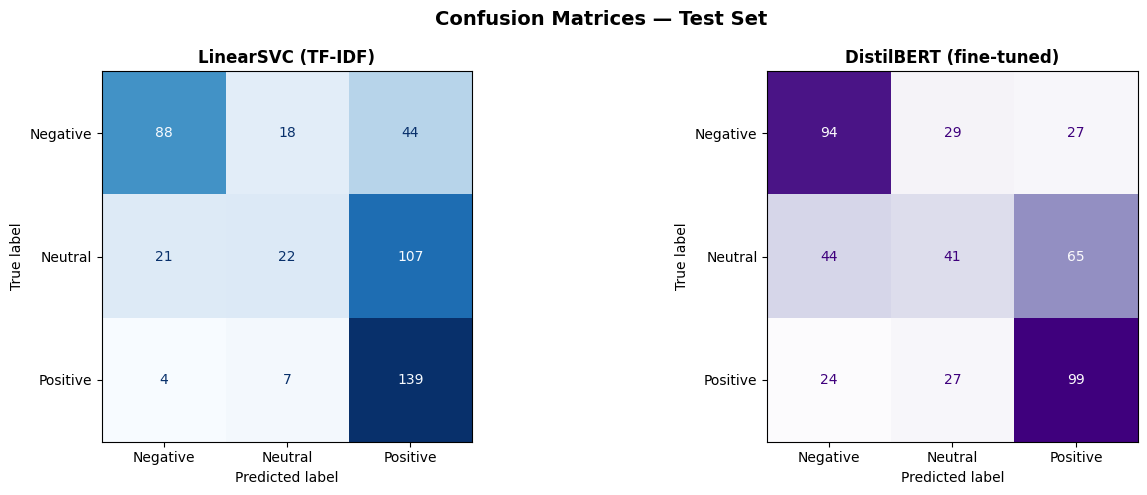

Saved comparison_confusion_matrices.png


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_cl = confusion_matrix(y_cl_test, y_cl_pred, labels=LABELS_ORDER)
ConfusionMatrixDisplay(cm_cl, display_labels=LABELS_ORDER).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('LinearSVC (TF-IDF)', fontweight='bold')

cm_tr = confusion_matrix(y_tr_test_str, y_tr_pred, labels=LABELS_ORDER)
ConfusionMatrixDisplay(cm_tr, display_labels=LABELS_ORDER).plot(
    ax=axes[1], colorbar=False, cmap='Purples')
axes[1].set_title('DistilBERT (fine-tuned)', fontweight='bold')

plt.suptitle('Confusion Matrices — Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{ASSETS_DIR}/comparison_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved comparison_confusion_matrices.png')

In [17]:
import time

# Time classical model on test set
t0 = time.time()
_ = clf.predict(tfidf.transform(X_cl_test))
cl_time = (time.time() - t0) * 1000

# Time transformer on test set
t0 = time.time()
with torch.no_grad():
    for input_ids, attention_mask in dl:
        _ = model(input_ids.to(device), attention_mask=attention_mask.to(device)).logits
tr_time = (time.time() - t0) * 1000

speed_df = pd.DataFrame({
    'Model'      : ['LinearSVC', 'DistilBERT'],
    'Macro-F1'   : [cl_f1, tr_f1],
    'Latency(ms)': [cl_time, tr_time],
})

fig = go.Figure(go.Scatter(
    x=speed_df['Latency(ms)'], y=speed_df['Macro-F1'],
    mode='markers+text',
    text=speed_df['Model'], textposition='top center',
    marker=dict(size=16, color=['#6366f1', '#22c55e']),
))
fig.update_layout(
    title='Speed vs Accuracy Trade-off',
    xaxis_title='Inference Latency (ms, full test set)',
    yaxis_title='Macro-F1',
    yaxis=dict(range=[0, 1]),
    height=450,
)
fig.show()

In [18]:
summary = pd.DataFrame({
    'Model'       : ['LinearSVC (TF-IDF)', 'DistilBERT (fine-tuned)'],
    'Accuracy'    : [round(cl_acc, 4), round(tr_acc, 4)],
    'Macro-F1'    : [round(cl_f1,  4), round(tr_f1,  4)],
    'Latency(ms)' : [round(cl_time, 1), round(tr_time, 1)],
    'Size'        : ['~few MB', '~250 MB'],
    'Interpretable': ['Yes', 'Limited'],
})

print(summary.to_string(index=False))

# Save summary
summary.to_csv(f'{ASSETS_DIR}/model_comparison_summary.csv', index=False)
print('\nSaved model_comparison_summary.csv')

                  Model  Accuracy  Macro-F1  Latency(ms)    Size Interpretable
     LinearSVC (TF-IDF)    0.5533    0.5081        296.4 ~few MB           Yes
DistilBERT (fine-tuned)    0.5200    0.5051      61928.7 ~250 MB       Limited

Saved model_comparison_summary.csv


In [20]:
winner    = 'DistilBERT' if tr_f1 > cl_f1 else 'LinearSVC'
f1_delta  = abs(tr_f1 - cl_f1)

print('=' * 55)
print(f'  Winner by Macro-F1 : {winner}')
print(f'  F1 delta           : +{f1_delta:.4f}')
print('=' * 55)
print()
print('Recommendation:')
print('  • Use DistilBERT for production — higher accuracy,')
print('    better handling of context and ambiguous feedback.')
print('  • Use LinearSVC for lightweight / real-time serving')
print('    where latency or compute cost is a constraint.')
print()


  Winner by Macro-F1 : LinearSVC
  F1 delta           : +0.0031

Recommendation:
  • Use DistilBERT for production — higher accuracy,
    better handling of context and ambiguous feedback.
  • Use LinearSVC for lightweight / real-time serving
    where latency or compute cost is a constraint.

